# Normative Demand: Выпечка сытная, 35 пекарен

Компактный исследовательский ноутбук без разбиения на отдельные эксперименты.

Идея:
- работаем только с категорией `Выпечка сытная`
- ограничиваемся 35 пекарнями
- считаем простые и интерпретируемые опоры для норматива
- сразу смотрим таблицы и графики

In [1]:
%matplotlib inline

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

DAILY_PATH = ROOT / "data/processed/sku_daily_research_panel.csv"
CATEGORY_NAME = "Выпечка сытная"
N_BAKERIES = 35
CHUNKSIZE = 250_000
MIN_HISTORY_DAYS = 28

DATE_COL = "date"
BAKERY_COL = "bakery_id"
SKU_COL = "product_id"
SALES_COL = "observed_sales_qty"
DOW_COL = "dow"

USECOLS = [
    "date",
    "bakery_id",
    "bakery_name",
    "city",
    "product_id",
    "product_name",
    "category_name",
    "observed_sales_qty",
    "bakery_sales_qty_total",
    "category_sales_qty_in_bakery_day",
    "sku_sales_share_in_bakery_day",
    "sku_sales_share_in_category_day",
    "release_qty",
    "dow",
]

ROOT

WindowsPath('c:/Users/dns/Desktop/Projects/demand-forecasting-model')

## 1. Вспомогательные функции

In [ ]:
def _rolling_median(series: pd.Series, window: int = 28, min_periods: int = 7) -> pd.Series:
    return series.rolling(window=window, min_periods=min_periods).median().bfill().ffill().fillna(0.0)


def _weekday_factor(group: pd.DataFrame, value_col: str) -> pd.Series:
    weekday_mean = group.groupby(DOW_COL, observed=True)[value_col].mean()
    overall_mean = float(group[value_col].mean())
    if overall_mean <= 1e-12:
        factors = pd.Series(1.0, index=range(7), dtype=float)
    else:
        factors = (weekday_mean / overall_mean).reindex(range(7)).fillna(1.0)
        factor_mean = float(factors.mean())
        factors = factors if factor_mean <= 1e-12 else factors / factor_mean
    return factors


def _safe_corr(x: pd.Series, y: pd.Series) -> float:
    xv = pd.to_numeric(x, errors="coerce")
    yv = pd.to_numeric(y, errors="coerce")
    valid = xv.notna() & yv.notna()
    if valid.sum() < 3:
        return np.nan
    xv = xv[valid]
    yv = yv[valid]
    if xv.nunique() < 2 or yv.nunique() < 2:
        return np.nan
    return float(np.corrcoef(xv, yv)[0, 1])


def load_category_sample(
    path: str | Path,
    category_name: str,
    n_bakeries: int = 35,
    chunksize: int = 250_000,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    bakery_stats_parts = []
    for chunk in pd.read_csv(path, encoding="utf-8-sig", usecols=USECOLS, chunksize=chunksize, low_memory=True):
        chunk = chunk.loc[chunk["category_name"].astype(str) == category_name, ["bakery_id", "bakery_name", SALES_COL]].copy()
        if chunk.empty:
            continue
        chunk["bakery_id"] = chunk["bakery_id"].astype(str)
        chunk[SALES_COL] = pd.to_numeric(chunk[SALES_COL], errors="coerce").fillna(0.0)
        bakery_stats_parts.append(
            chunk.groupby(["bakery_id", "bakery_name"], as_index=False)
            .agg(rows=(SALES_COL, "size"), sales_sum=(SALES_COL, "sum"))
        )

    bakery_stats = pd.concat(bakery_stats_parts, ignore_index=True)
    bakery_stats = bakery_stats.groupby(["bakery_id", "bakery_name"], as_index=False).sum()
    bakery_stats = bakery_stats.sort_values(["sales_sum", "rows"], ascending=False).reset_index(drop=True)
    selected_bakeries = bakery_stats.head(n_bakeries)[["bakery_id", "bakery_name"]].copy()
    selected_ids = set(selected_bakeries["bakery_id"].astype(str))

    parts = []
    for chunk in pd.read_csv(path, encoding="utf-8-sig", usecols=USECOLS, chunksize=chunksize, low_memory=True):
        chunk = chunk.loc[chunk["category_name"].astype(str) == category_name].copy()
        if chunk.empty:
            continue
        chunk["bakery_id"] = chunk["bakery_id"].astype(str)
        chunk = chunk.loc[chunk["bakery_id"].isin(selected_ids)].copy()
        if chunk.empty:
            continue
        chunk["product_id"] = chunk["product_id"].astype(str)
        chunk[DATE_COL] = pd.to_datetime(chunk[DATE_COL], errors="coerce")
        chunk = chunk.dropna(subset=[DATE_COL, "bakery_id", "product_id"])
        for col in [SALES_COL, "bakery_sales_qty_total", "category_sales_qty_in_bakery_day", "sku_sales_share_in_bakery_day", "sku_sales_share_in_category_day", "release_qty"]:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
        dow_numeric = pd.to_numeric(chunk[DOW_COL], errors="coerce")
        chunk[DOW_COL] = dow_numeric.fillna(chunk[DATE_COL].dt.weekday).astype(int)
        parts.append(chunk)

    df = pd.concat(parts, ignore_index=True)
    df = df.sort_values(["bakery_id", "product_id", DATE_COL]).reset_index(drop=True)
    return df, bakery_stats


def build_pair_profile(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for (bakery_id, product_id), group in df.groupby(["bakery_id", "product_id"], observed=True):
        observed = pd.to_numeric(group[SALES_COL], errors="coerce").fillna(0.0)
        release = pd.to_numeric(group["release_qty"], errors="coerce").fillna(0.0)
        bakery_total = pd.to_numeric(group["bakery_sales_qty_total"], errors="coerce")
        category_total = pd.to_numeric(group["category_sales_qty_in_bakery_day"], errors="coerce")
        share_bakery = pd.to_numeric(group["sku_sales_share_in_bakery_day"], errors="coerce")
        share_category = pd.to_numeric(group["sku_sales_share_in_category_day"], errors="coerce")
        records.append({
            "bakery_id": bakery_id,
            "product_id": product_id,
            "bakery_name": group["bakery_name"].iloc[0],
            "product_name": group["product_name"].iloc[0],
            "city": group["city"].iloc[0],
            "n_days": int(len(group)),
            "date_min": group[DATE_COL].min(),
            "date_max": group[DATE_COL].max(),
            "observed_mean": float(observed.mean()),
            "zero_share": float((observed <= 0).mean()),
            "corr_release": _safe_corr(observed, release),
            "corr_bakery_total": _safe_corr(observed, bakery_total),
            "corr_category_total": _safe_corr(observed, category_total),
            "share_bakery_mean": float(share_bakery.mean()) if share_bakery.notna().any() else np.nan,
            "share_bakery_cv": float(share_bakery.std(ddof=0) / share_bakery.mean()) if share_bakery.notna().any() and float(share_bakery.mean()) > 1e-12 else np.nan,
            "share_category_mean": float(share_category.mean()) if share_category.notna().any() else np.nan,
            "share_category_cv": float(share_category.std(ddof=0) / share_category.mean()) if share_category.notna().any() and float(share_category.mean()) > 1e-12 else np.nan,
        })
    return pd.DataFrame.from_records(records)


def build_simple_normatives(df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    bakery_daily = (
        df.groupby([DATE_COL, "bakery_id", DOW_COL], observed=True, as_index=False)
        .agg(bakery_sales_qty_total=("bakery_sales_qty_total", "max"), category_sales_qty_in_bakery_day=("category_sales_qty_in_bakery_day", "max"))
    )
    bakery_daily_map = bakery_daily[[DATE_COL, "bakery_id", "bakery_sales_qty_total", "category_sales_qty_in_bakery_day"]].copy()

    for _, group in df.groupby(["bakery_id", "product_id"], observed=True, sort=False):
        group = group.sort_values(DATE_COL).copy()
        observed = pd.to_numeric(group[SALES_COL], errors="coerce").fillna(0.0)
        release = pd.to_numeric(group["release_qty"], errors="coerce").fillna(0.0)
        weekday_factor = _weekday_factor(group, SALES_COL)
        observed_trend = _rolling_median(observed)
        release_trend = _rolling_median(release)
        share_bakery = _rolling_median(pd.to_numeric(group["sku_sales_share_in_bakery_day"], errors="coerce").fillna(0.0))
        share_category = _rolling_median(pd.to_numeric(group["sku_sales_share_in_category_day"], errors="coerce").fillna(0.0))

        group["norm_sales_weekday"] = (observed_trend * group[DOW_COL].map(weekday_factor).astype(float)).clip(lower=0.0)
        group["norm_release_weekday"] = (release_trend * group[DOW_COL].map(weekday_factor).astype(float)).clip(lower=0.0)
        group["norm_blend_50_50"] = (0.5 * group["norm_sales_weekday"] + 0.5 * group["norm_release_weekday"]).clip(lower=0.0)
        group["norm_bakery_share"] = (pd.to_numeric(group["bakery_sales_qty_total"], errors="coerce").fillna(0.0) * share_bakery).clip(lower=0.0)
        group["norm_category_share"] = (pd.to_numeric(group["category_sales_qty_in_bakery_day"], errors="coerce").fillna(0.0) * share_category).clip(lower=0.0)
        parts.append(group)

    return pd.concat(parts, ignore_index=True).sort_values(["bakery_id", "product_id", DATE_COL]).reset_index(drop=True)


def score_normatives(df: pd.DataFrame) -> pd.DataFrame:
    candidate_cols = [
        "norm_sales_weekday",
        "norm_release_weekday",
        "norm_blend_50_50",
        "norm_bakery_share",
        "norm_category_share",
    ]
    records = []
    for (bakery_id, product_id), group in df.groupby(["bakery_id", "product_id"], observed=True):
        observed = pd.to_numeric(group[SALES_COL], errors="coerce").fillna(0.0)
        base = {
            "bakery_id": bakery_id,
            "product_id": product_id,
            "bakery_name": group["bakery_name"].iloc[0],
            "product_name": group["product_name"].iloc[0],
            "n_days": int(len(group)),
            "observed_mean": float(observed.mean()),
        }
        for col in candidate_cols:
            candidate = pd.to_numeric(group[col], errors="coerce").fillna(0.0)
            base[f"{col}_mean"] = float(candidate.mean())
            base[f"{col}_ratio"] = float(candidate.mean() / observed.mean()) if float(observed.mean()) > 1e-12 else np.nan
            base[f"{col}_corr_observed"] = _safe_corr(candidate, observed)
            base[f"{col}_corr_release"] = _safe_corr(candidate, group["release_qty"])
            base[f"{col}_corr_bakery_total"] = _safe_corr(candidate, group["bakery_sales_qty_total"])
        records.append(base)
    return pd.DataFrame.from_records(records)


def plot_pair(df: pd.DataFrame, bakery_id: str, product_id: str, tail_days: int | None = 90) -> None:
    bakery_id = str(bakery_id)
    product_id = str(product_id)
    plot_df = df.loc[(df["bakery_id"].astype(str) == bakery_id) & (df["product_id"].astype(str) == product_id)].copy()
    if plot_df.empty:
        print("No rows found")
        return
    plot_df = plot_df.sort_values(DATE_COL)
    if tail_days is not None:
        plot_df = plot_df.tail(tail_days)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    axes[0].plot(plot_df[DATE_COL], plot_df[SALES_COL], label="observed", linewidth=2)
    axes[0].plot(plot_df[DATE_COL], plot_df["norm_sales_weekday"], label="norm_sales_weekday", linewidth=1.6)
    axes[0].plot(plot_df[DATE_COL], plot_df["norm_release_weekday"], label="norm_release_weekday", linewidth=1.6)
    axes[0].plot(plot_df[DATE_COL], plot_df["norm_bakery_share"], label="norm_bakery_share", linewidth=1.6)
    axes[0].plot(plot_df[DATE_COL], plot_df["norm_category_share"], label="norm_category_share", linewidth=1.6)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(f"bakery_id={bakery_id}, product_id={product_id}")

    axes[1].plot(plot_df[DATE_COL], plot_df["release_qty"], label="release_qty", linewidth=1.8)
    axes[1].plot(plot_df[DATE_COL], plot_df["bakery_sales_qty_total"], label="bakery_total", linewidth=1.5)
    axes[1].plot(plot_df[DATE_COL], plot_df["category_sales_qty_in_bakery_day"], label="category_total", linewidth=1.5)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 2. Загружаем выборку

In [3]:
sample_df, bakery_stats = load_category_sample(
    DAILY_PATH,
    category_name=CATEGORY_NAME,
    n_bakeries=N_BAKERIES,
    chunksize=CHUNKSIZE,
)

print(f"rows: {len(sample_df):,}")
print(f"bakeries: {sample_df['bakery_id'].nunique():,}")
print(f"products: {sample_df['product_id'].nunique():,}")
display(bakery_stats.head(35))

rows: 290,446
bakeries: 35
products: 31


,bakery_id,bakery_name,rows,sales_sum
0,110,Шамиля Усманова 47 Наб Челны,8307,469144.105
1,16,Кулагина 4 Казань,8229,467496.220
2,105,Фучика 96 Казань,8678,464538.865
3,79,Ильича 19/43 Казань,8395,458678.103
4,142,Баки Урманче 6 Казань,8596,424739.257
5,18,Хади Такташ 105 Казань,8599,412778.312
6,137,Татарстан 53А Казань,8672,407716.500
7,30,Баумана 29/11 Казань,8453,406924.691
8,62,Шамиля Усманова 16А Казань,7882,393016.000
9,29,Айдарова 8А корп 1 Казань,8260,392107.500


## 3. Профиль пар bakery x SKU

In [4]:
pair_profile = build_pair_profile(sample_df)
display(pair_profile.head())
display(pair_profile[["n_days", "observed_mean", "zero_share", "corr_release", "corr_bakery_total", "corr_category_total"]].describe())

,bakery_id,product_id,bakery_name,product_name,city,n_days,date_min,date_max,observed_mean,zero_share,corr_release,corr_bakery_total,corr_category_total,share_bakery_mean,share_bakery_cv,share_category_mean,share_category_cv
0,102,10093,Татарстан 16 Казань,Пирожок Ризотто,Казань,71,2025-12-22,2026-03-02,9.098592,0.028169,0.688120,0.401795,0.397064,0.006543,0.407925,0.014079,0.416698
1,102,10298,Татарстан 16 Казань,Пирожок с горбушей,Казань,483,2025-01-15,2026-05-12,13.987578,0.004141,0.777803,0.382417,0.400401,0.008568,0.384448,0.018712,0.379112
2,102,10340,Татарстан 16 Казань,Кыстыбый П,Казань,483,2025-01-15,2026-05-12,40.695652,0.006211,0.918913,0.419617,0.424511,0.025010,0.280150,0.054762,0.284258
3,102,10346,Татарстан 16 Казань,Сосиска под шубой,Казань,483,2025-01-15,2026-05-12,84.434783,0.004141,0.951151,0.856556,0.839314,0.048818,0.262830,0.106757,0.261013
4,102,10347,Татарстан 16 Казань,Жар пицца с курицей,Казань,483,2025-01-15,2026-05-12,50.374741,0.004141,0.948240,0.747555,0.730682,0.029534,0.280858,0.064602,0.282436


,n_days,observed_mean,zero_share,corr_release,corr_bakery_total,corr_category_total
count,890.000000,890.000000,890.000000,878.000000,883.000000,883.000000
mean,326.343820,34.018494,0.079202,0.674571,0.419528,0.446885
std,180.539601,36.363821,0.189305,0.203686,0.224851,0.224901
min,1.000000,0.091335,0.000000,-0.026050,-0.990954,-0.821711
25%,147.250000,10.374554,0.004141,0.559357,0.289453,0.317835
50%,477.000000,20.735151,0.006211,0.696427,0.430703,0.460659
75%,483.000000,45.447205,0.046512,0.832227,0.563111,0.599372
max,483.000000,249.254658,0.976581,1.000000,0.984027,0.985201


## 4. Фильтр на нормальную длину истории

In [5]:
eligible_pairs = pair_profile.loc[pair_profile["n_days"] >= MIN_HISTORY_DAYS, ["bakery_id", "product_id"]].copy()
eligible_df = sample_df.merge(eligible_pairs, on=["bakery_id", "product_id"], how="inner")
eligible_profile = pair_profile.merge(eligible_pairs, on=["bakery_id", "product_id"], how="inner")

print(f"eligible rows: {len(eligible_df):,}")
print(f"eligible pairs: {len(eligible_profile):,}")
display(eligible_profile[["n_days", "observed_mean", "zero_share"]].describe())

eligible rows: 290,297
eligible pairs: 866


,n_days,observed_mean,zero_share
count,866.000000,866.000000,866.000000
mean,335.215935,34.455842,0.081187
std,174.858723,36.606046,0.191436
min,28.000000,0.091335,0.000000
25%,161.000000,10.670322,0.004141
50%,483.000000,21.076863,0.006211
75%,483.000000,45.751553,0.048780
max,483.000000,249.254658,0.976581


## 5. Считаем несколько простых нормативов

In [6]:
norm_df = build_simple_normatives(eligible_df)
norm_scores = score_normatives(norm_df)

summary = pd.DataFrame({
    "candidate": [
        "norm_sales_weekday",
        "norm_release_weekday",
        "norm_blend_50_50",
        "norm_bakery_share",
        "norm_category_share",
    ],
    "mean_ratio": [
        norm_scores["norm_sales_weekday_ratio"].mean(),
        norm_scores["norm_release_weekday_ratio"].mean(),
        norm_scores["norm_blend_50_50_ratio"].mean(),
        norm_scores["norm_bakery_share_ratio"].mean(),
        norm_scores["norm_category_share_ratio"].mean(),
    ],
    "mean_corr_observed": [
        norm_scores["norm_sales_weekday_corr_observed"].mean(),
        norm_scores["norm_release_weekday_corr_observed"].mean(),
        norm_scores["norm_blend_50_50_corr_observed"].mean(),
        norm_scores["norm_bakery_share_corr_observed"].mean(),
        norm_scores["norm_category_share_corr_observed"].mean(),
    ],
    "mean_corr_release": [
        norm_scores["norm_sales_weekday_corr_release"].mean(),
        norm_scores["norm_release_weekday_corr_release"].mean(),
        norm_scores["norm_blend_50_50_corr_release"].mean(),
        norm_scores["norm_bakery_share_corr_release"].mean(),
        norm_scores["norm_category_share_corr_release"].mean(),
    ],
    "mean_corr_bakery_total": [
        norm_scores["norm_sales_weekday_corr_bakery_total"].mean(),
        norm_scores["norm_release_weekday_corr_bakery_total"].mean(),
        norm_scores["norm_blend_50_50_corr_bakery_total"].mean(),
        norm_scores["norm_bakery_share_corr_bakery_total"].mean(),
        norm_scores["norm_category_share_corr_bakery_total"].mean(),
    ],
})

display(summary.sort_values("mean_corr_observed", ascending=False))

,candidate,mean_ratio,mean_corr_observed,mean_corr_release,mean_corr_bakery_total
4,norm_category_share,0.947303,0.658648,0.549442,0.704894
3,norm_bakery_share,0.947188,0.641760,0.543310,0.736673
0,norm_sales_weekday,0.988698,0.509224,0.419110,0.408417
2,norm_blend_50_50,1.552834,0.483584,0.439927,0.382208
1,norm_release_weekday,2.116969,0.461708,0.436468,0.363301


## 6. Какие пары смотреть глазами

In [7]:
view_df = norm_scores.merge(
    eligible_profile[["bakery_id", "product_id", "corr_release", "corr_bakery_total", "corr_category_total", "share_bakery_cv", "share_category_cv"]],
    on=["bakery_id", "product_id"],
    how="left",
)

print("Top release-anchored pairs")
display(view_df.sort_values(["corr_release", "n_days", "observed_mean"], ascending=[False, False, False]).head(10))

print("Top bakery-anchored pairs")
display(view_df.sort_values(["corr_bakery_total", "n_days", "observed_mean"], ascending=[False, False, False]).head(10))

print("Top category-anchored pairs")
display(view_df.sort_values(["corr_category_total", "n_days", "observed_mean"], ascending=[False, False, False]).head(10))

Top release-anchored pairs


,bakery_id,product_id,bakery_name,product_name,n_days,observed_mean,norm_sales_weekday_mean,norm_sales_weekday_ratio,norm_sales_weekday_corr_observed,norm_sales_weekday_corr_release,...,norm_category_share_mean,norm_category_share_ratio,norm_category_share_corr_observed,norm_category_share_corr_release,norm_category_share_corr_bakery_total,corr_release,corr_bakery_total,corr_category_total,share_bakery_cv,share_category_cv
775,79,10658,Ильича 19/43 Казань,я_не исп Пирожок,138,0.876812,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.998195,0.139705,0.050713,0.901233,0.906224
24,102,64,Татарстан 16 Казань,Беккен капуста пост,444,2.265766,1.317764,0.581597,0.621755,0.621157,...,0.985454,0.434932,0.727719,0.729175,0.436955,0.996259,0.221710,0.204333,0.690673,0.674084
836,94,4241,Розы Люксембург 4 Чебоксары,ЖарЧизбургер,197,2.847716,2.854468,1.002371,0.644686,0.642900,...,2.132283,0.748770,0.822060,0.821991,0.680036,0.994483,-0.030145,-0.044253,0.222887,0.237515
8,102,10658,Татарстан 16 Казань,я_не исп Пирожок,153,0.679739,0.103327,0.152010,0.624960,0.622472,...,0.089316,0.131398,0.631108,0.589854,0.243390,0.988066,0.478460,0.531538,0.511567,0.498622
287,16,11300,Кулагина 4 Казань,Тарталетка сытный,58,13.568966,17.370732,1.280181,0.747495,0.760096,...,15.210924,1.121008,0.863994,0.861460,0.803633,0.987850,0.540146,0.543936,0.489038,0.491894
237,142,11300,Баки Урманче 6 Казань,Тарталетка сытный,140,4.685714,6.303163,1.345187,0.851939,0.863858,...,4.739705,1.011523,0.932128,0.944824,0.619807,0.987042,0.516241,0.510599,0.462173,0.471641
248,142,64,Баки Урманче 6 Казань,Беккен капуста пост,448,3.558036,2.812495,0.790463,0.644198,0.641095,...,2.323879,0.653135,0.747372,0.746853,0.382743,0.982326,0.232865,0.196455,0.537873,0.532509
296,16,4944,Кулагина 4 Казань,Пирожок капуста и курица,322,13.804348,16.323289,1.182475,0.789758,0.792125,...,13.866288,1.004487,0.891641,0.892049,0.898703,0.981297,0.573639,0.596273,0.269775,0.268694
800,89,10658,Парина 6 Казань,я_не исп Пирожок,49,2.836735,2.606886,0.918974,0.417127,0.393196,...,1.760345,0.620553,0.779939,0.773987,0.062789,0.980687,0.353463,0.425028,0.459574,0.447124
282,16,10658,Кулагина 4 Казань,я_не исп Пирожок,203,0.261084,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.979123,0.898377,0.875121,0.627264,0.622408


Top bakery-anchored pairs


,bakery_id,product_id,bakery_name,product_name,n_days,observed_mean,norm_sales_weekday_mean,norm_sales_weekday_ratio,norm_sales_weekday_corr_observed,norm_sales_weekday_corr_release,...,norm_category_share_mean,norm_category_share_ratio,norm_category_share_corr_observed,norm_category_share_corr_release,norm_category_share_corr_bakery_total,corr_release,corr_bakery_total,corr_category_total,share_bakery_cv,share_category_cv
399,22,61,Сибирский Тракт 25 Казань,я_не_исп Элеш,33,51.757576,57.118080,1.103569,0.860716,0.836242,...,50.757479,0.980677,0.898984,0.815034,0.979745,0.837604,0.911567,0.904496,0.183933,0.177645
282,16,10658,Кулагина 4 Казань,я_не исп Пирожок,203,0.261084,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.979123,0.898377,0.875121,0.627264,0.622408
277,16,10346,Кулагина 4 Казань,Сосиска под шубой,483,89.145217,93.454842,1.048344,0.703553,0.636286,...,88.266639,0.990144,0.892884,0.796881,0.939943,0.880824,0.873901,0.875798,0.174918,0.167944
534,30,1071,Баумана 29/11 Казань,Треугольник курица безд,483,150.175983,140.461744,0.935314,0.626086,0.496737,...,145.079705,0.966065,0.888345,0.713254,0.927410,0.792344,0.867860,0.904685,0.244255,0.214422
742,62,57,Шамиля Усманова 16А Казань,Сосиска в тесте,483,72.743271,76.820698,1.056052,0.687115,0.666995,...,72.864304,1.001664,0.896623,0.854856,0.919433,0.926022,0.866977,0.887678,0.241875,0.227463
78,107,10346,Четаева 46А Казань,Сосиска под шубой,483,56.496894,58.649925,1.038109,0.677748,0.628230,...,56.231542,0.995303,0.869865,0.764551,0.881983,0.828728,0.861529,0.809189,0.223307,0.237569
3,102,10346,Татарстан 16 Казань,Сосиска под шубой,483,84.434783,92.116986,1.090984,0.761115,0.746162,...,85.685434,1.014812,0.856693,0.813758,0.859869,0.951151,0.856556,0.839314,0.262830,0.261013
535,30,1076,Баумана 29/11 Казань,Треугольник говядина безд,483,122.153209,115.140794,0.942593,0.625976,0.530384,...,118.191358,0.967567,0.862696,0.744220,0.902169,0.867864,0.854784,0.895499,0.297119,0.265764
723,62,10346,Шамиля Усманова 16А Казань,Сосиска под шубой,483,45.387164,47.563852,1.047958,0.720033,0.704883,...,44.472794,0.979854,0.859272,0.817941,0.860102,0.929932,0.853286,0.850479,0.306731,0.301712
10,102,1071,Татарстан 16 Казань,Треугольник курица безд,483,157.482402,164.518374,1.044678,0.696712,0.632764,...,157.166803,0.997996,0.874101,0.775383,0.946458,0.869562,0.851221,0.854675,0.153162,0.144024


Top category-anchored pairs


,bakery_id,product_id,bakery_name,product_name,n_days,observed_mean,norm_sales_weekday_mean,norm_sales_weekday_ratio,norm_sales_weekday_corr_observed,norm_sales_weekday_corr_release,...,norm_category_share_mean,norm_category_share_ratio,norm_category_share_corr_observed,norm_category_share_corr_release,norm_category_share_corr_bakery_total,corr_release,corr_bakery_total,corr_category_total,share_bakery_cv,share_category_cv
534,30,1071,Баумана 29/11 Казань,Треугольник курица безд,483,150.175983,140.461744,0.935314,0.626086,0.496737,...,145.079705,0.966065,0.888345,0.713254,0.927410,0.792344,0.867860,0.904685,0.244255,0.214422
399,22,61,Сибирский Тракт 25 Казань,я_не_исп Элеш,33,51.757576,57.118080,1.103569,0.860716,0.836242,...,50.757479,0.980677,0.898984,0.815034,0.979745,0.837604,0.911567,0.904496,0.183933,0.177645
535,30,1076,Баумана 29/11 Казань,Треугольник говядина безд,483,122.153209,115.140794,0.942593,0.625976,0.530384,...,118.191358,0.967567,0.862696,0.744220,0.902169,0.867864,0.854784,0.895499,0.297119,0.265764
742,62,57,Шамиля Усманова 16А Казань,Сосиска в тесте,483,72.743271,76.820698,1.056052,0.687115,0.666995,...,72.864304,1.001664,0.896623,0.854856,0.919433,0.926022,0.866977,0.887678,0.241875,0.227463
729,62,1071,Шамиля Усманова 16А Казань,Треугольник курица безд,483,184.322981,188.901380,1.024839,0.652550,0.581793,...,185.372065,1.005692,0.900738,0.736714,0.941550,0.802383,0.848898,0.881350,0.153006,0.133059
277,16,10346,Кулагина 4 Казань,Сосиска под шубой,483,89.145217,93.454842,1.048344,0.703553,0.636286,...,88.266639,0.990144,0.892884,0.796881,0.939943,0.880824,0.873901,0.875798,0.174918,0.167944
282,16,10658,Кулагина 4 Казань,я_не исп Пирожок,203,0.261084,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.979123,0.898377,0.875121,0.627264,0.622408
309,18,1071,Хади Такташ 105 Казань,Треугольник курица безд,483,184.666253,184.184877,0.997393,0.610735,0.510275,...,183.345977,0.992850,0.880955,0.710426,0.950223,0.763463,0.827504,0.861267,0.144401,0.129497
794,89,10340,Парина 6 Казань,Кыстыбый П,483,164.542443,168.518435,1.024164,0.670855,0.573347,...,165.204084,1.004021,0.876151,0.664792,0.927882,0.749606,0.842984,0.856517,0.169700,0.167755
234,142,1071,Баки Урманче 6 Казань,Треугольник курица безд,483,209.446716,210.606032,1.005535,0.735705,0.565444,...,209.235679,0.998992,0.902960,0.684801,0.906711,0.781668,0.832875,0.856454,0.147566,0.132505


## 7. График по конкретной паре

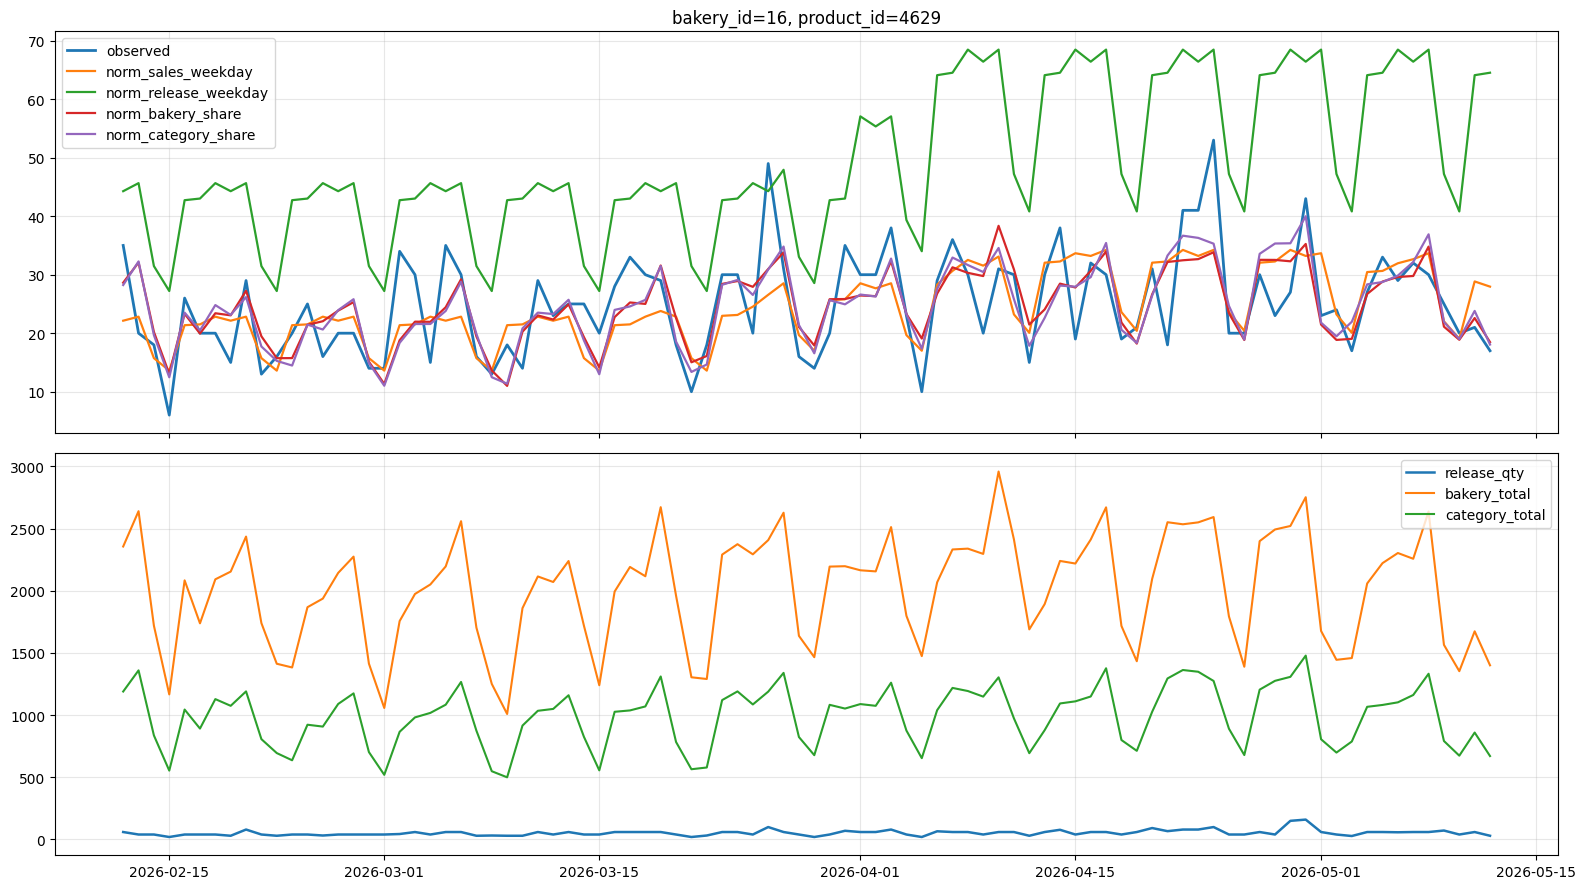

bakery_id                             16
product_id                          4629
bakery_name            Кулагина 4 Казань
product_name            Конвертик курица
n_days                               483
corr_release                     0.93237
corr_bakery_total               0.641965
corr_category_total             0.629799
Name: 295, dtype: object

In [63]:
row = view_df.sort_values(["corr_release", "n_days"], ascending=[False, False]).iloc[64]
plot_pair(norm_df, row["bakery_id"], row["product_id"], tail_days=90)
row[["bakery_id", "product_id", "bakery_name", "product_name", "n_days", "corr_release", "corr_bakery_total", "corr_category_total"]]